# Manufacturing EDA Project

## 프로젝트 개요

이 프로젝트는 AI 모델 개발을 위한 데이터 분석 기초 역량을 기르기 위해 수행하는 제조 데이터 EDA 프로젝트이다.

AI4I 2020 Predictive Maintenance Dataset을 사용하여 제조 설비의 센서 데이터와 기계 고장 여부 간의 관계를 분석한다.

## 분석 목표

- 제조 데이터의 구조를 파악한다.
- 결측치, 중복값, 이상치를 확인한다.
- 제품 유형별 고장률을 분석한다.
- 센서 변수의 분포를 시각화한다.
- 센서 변수와 고장 여부의 관계를 탐색한다.
- 머신러닝 모델 개발을 위한 train/test split을 수행한다.

# 0. 환경 준비

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.model_selection import train_test_split

BASE_DIR = Path("..")
DATA_DIR = BASE_DIR / "data"
FIGURE_DIR = BASE_DIR / "figures"
REPORT_DIR = BASE_DIR / "reports"

FIGURE_DIR.mkdir(exist_ok=True)
REPORT_DIR.mkdir(exist_ok=True)

# 1. 데이터 불러오기

프로젝트의 `data/` 폴더에 저장된 AI4I 2020 Predictive Maintenance Dataset을 Pandas DataFrame으로 불러온다.

데이터를 불러온 뒤 행/열 개수와 상위 5개 데이터를 확인하여 정상적으로 로드되었는지 점검한다.

In [20]:
df = pd.read_csv(DATA_DIR / "ai4i2020.csv")

print(df.shape)
df.head()

(10000, 14)


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 데이터 불러오기 결과

데이터는 총 10,000행과 14개 컬럼으로 구성되어 있다.

상위 5개 데이터를 확인한 결과, 제품 ID, 제품 유형, 온도, 회전 속도, 토크, 공구 마모 시간, 기계 고장 여부 관련 컬럼들이 포함되어 있음을 확인하였다.

# 2. 데이터 구조 확인

`info()`를 통해 컬럼별 데이터 타입과 결측치 여부를 확인하고, `describe()`를 통해 숫자형 컬럼의 기초 통계량을 확인한다.

In [21]:
df.info()

display(df.describe())
display(df.columns)

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


Index(['UDI', 'Product ID', 'Type', 'Air temperature [K]',
       'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]',
       'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF',
       'RNF'],
      dtype='str')

## 데이터 구조 확인 결과

AI4I 2020 Predictive Maintenance Dataset은 총 10,000행과 14개 컬럼으로 구성되어 있다.

모든 컬럼의 Non-Null Count가 10,000으로 확인되므로 현재 데이터에는 결측치가 존재하지 않는다.

데이터 타입은 숫자형 컬럼과 문자열 컬럼으로 구성되어 있다. 주요 센서 변수로는 공기 온도, 공정 온도, 회전 속도, 토크, 공구 마모 시간이 있으며, `Machine failure` 컬럼은 기계 고장 여부를 나타내는 라벨로 사용한다.

# 3. 컬럼명 정리

원본 컬럼명에는 공백, 단위, 대괄호가 포함되어 있어 코드 작성 시 불편할 수 있다.

분석에 자주 사용할 센서 변수와 라벨 컬럼명을 짧은 이름으로 변경한다.

In [22]:
df = df.rename(columns={
    "Air temperature [K]": "air_temp",
    "Process temperature [K]": "process_temp",
    "Rotational speed [rpm]": "rot_speed",
    "Torque [Nm]": "torque",
    "Tool wear [min]": "tool_wear",
    "Machine failure": "failure"
})

sensor_cols = [
    "air_temp",
    "process_temp",
    "rot_speed",
    "torque",
    "tool_wear"
]

df.head()

,UDI,Product ID,Type,air_temp,process_temp,rot_speed,torque,tool_wear,failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 컬럼명 정리 결과

분석에 자주 사용할 센서 변수와 라벨 컬럼명을 짧게 변경하였다.

이후 분석에서는 `air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear`를 주요 센서 변수로 사용하고, `failure`를 기계 고장 여부 라벨로 사용한다.

# 4. 고장 라벨 분포 확인

`failure` 컬럼의 값 분포를 확인하여 정상 데이터와 고장 데이터의 비율을 파악한다.

제조 데이터에서는 고장 데이터가 정상 데이터보다 적은 경우가 많으므로, 라벨 불균형 여부를 확인하는 것이 중요하다.

In [23]:
failure_count = df["failure"].value_counts()
failure_ratio = df["failure"].value_counts(normalize=True) * 100

display(failure_count)
display(failure_ratio)

failure
0    9661
1     339
Name: count, dtype: int64

failure
0    96.61
1     3.39
Name: proportion, dtype: float64

## 고장 라벨 분포 확인 결과

`failure = 0`은 정상 상태, `failure = 1`은 기계 고장을 의미한다.

failure_ratio : 3.39

라벨 분포를 확인한 결과 정상 데이터가 대부분을 차지하고, 고장 데이터의 비율은 상대적으로 낮게 나타났다.

따라서 이 데이터는 클래스 불균형이 존재하는 제조 데이터로 볼 수 있다. 이후 train/test split을 수행할 때 라벨 비율이 유지되도록 `stratify` 옵션을 사용하는 것이 적절하다.

# 5. 데이터 품질 확인

데이터 분석 전에 결측치, 중복값, 컬럼별 고유값 개수를 확인하여 데이터 품질을 점검한다.

결측치가 많거나 중복 데이터가 존재하면 이후 분석 결과나 머신러닝 모델 학습에 영향을 줄 수 있으므로, EDA 초반에 반드시 확인해야 한다.

In [24]:
quality_report = pd.DataFrame({
    "dtype": df.dtypes.astype(str),
    "missing_count": df.isnull().sum(),
    "missing_ratio": df.isnull().mean() * 100,
    "unique_count": df.nunique()
})

quality_report

,dtype,missing_count,missing_ratio,unique_count
UDI,int64,0,0.0,10000
Product ID,str,0,0.0,10000
Type,str,0,0.0,3
air_temp,float64,0,0.0,93
process_temp,float64,0,0.0,82
rot_speed,int64,0,0.0,941
torque,float64,0,0.0,577
tool_wear,int64,0,0.0,246
failure,int64,0,0.0,2
TWF,int64,0,0.0,2


In [25]:
duplicate_count = df.duplicated().sum()
duplicate_ratio = df.duplicated().mean() * 100

print("중복 행 개수:", duplicate_count)
print(f"중복 행 비율: {duplicate_ratio:.2f}%")

중복 행 개수: 0
중복 행 비율: 0.00%


In [26]:
quality_report.to_csv(
    REPORT_DIR / "data_quality_report.csv",
    encoding="utf-8-sig"
)

## 데이터 품질 확인 결과

컬럼별 결측치 개수와 결측치 비율을 확인한 결과, 모든 컬럼의 `missing_count`가 0이고 `missing_ratio`가 0.0으로 나타났다. 따라서 현재 데이터에는 결측치가 존재하지 않는다.

또한 전체 행 기준 중복값을 확인한 결과, 중복 행은 존재하지 않았다.

`UDI`와 `Product ID`는 각각 `unique_count`가 10,000으로, 모든 행마다 고유한 값을 가진다. 따라서 이 두 컬럼은 데이터 식별을 위한 ID 컬럼으로 볼 수 있으며, 이후 센서 분석이나 모델링 feature에서는 제외하는 것이 적절하다.

`Type` 컬럼은 고유값이 3개로, 제품 유형을 나타내는 범주형 변수이다. 이후 제품 유형별 고장률 분석에 활용할 수 있다.

`air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear` 컬럼은 주요 센서 및 공정 변수로 볼 수 있다. 이 변수들은 이후 분포 확인, 이상치 분석, 고장 여부와의 관계 분석에 사용한다.

`failure`, `TWF`, `HDF`, `PWF`, `OSF`, `RNF` 컬럼은 고유값이 2개인 이진 변수이다. 이 중 `failure`는 전체 기계 고장 여부를 나타내는 라벨로 사용한다.

# 6. 제품 유형별 데이터 분포와 고장률 분석

`Type` 컬럼은 제품 유형을 나타내는 범주형 변수이다.

먼저 제품 유형별 데이터 개수를 확인하여 특정 유형에 데이터가 편중되어 있는지 확인한다.

이후 제품 유형별 고장률을 계산하여 제품 유형에 따라 고장 발생 비율에 차이가 있는지 분석한다.

In [ ]:
type_count = df["Type"].value_counts()
type_ratio = df["Type"].value_counts(normalize=True) * 100

display(type_count)
display(type_ratio)

Type
L    6000
M    2997
H    1003
Name: count, dtype: int64

Type
L    60.00
M    29.97
H    10.03
Name: proportion, dtype: float64

In [28]:
type_failure_rate = df.groupby("Type")["failure"].mean() * 100

type_failure_rate

Type
H    2.093719
L    3.916667
M    2.769436
Name: failure, dtype: float64

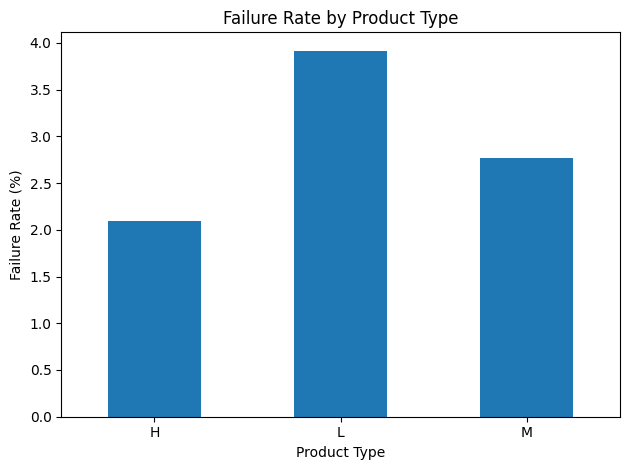

In [29]:
type_failure_rate.plot(kind="bar")

plt.title("Failure Rate by Product Type")
plt.xlabel("Product Type")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(FIGURE_DIR / "failure_rate_by_type.png")
plt.show()

## 제품 유형별 고장률 분석 결과

제품 유형별 고장률을 계산한 결과, `L` 타입의 고장률이 약 3.92%로 가장 높게 나타났다.

`M` 타입의 고장률은 약 2.77%, `H` 타입의 고장률은 약 2.09%로 확인되었다.

즉, 제품 유형에 따라 고장률에 차이가 존재하며, 이 데이터에서는 `L` 타입 제품이 상대적으로 고장 발생 비율이 높은 것으로 나타났다.

# 7. 센서 변수 분포 분석

제조 데이터에서 센서 변수는 장비 상태와 고장 여부를 파악하는 데 중요한 feature이다.

이번 단계에서는 주요 센서 변수의 분포를 히스토그램으로 시각화하여 각 센서값이 어떤 범위에 집중되어 있는지 확인한다.

분석 대상 센서 변수는 다음과 같다.

- `air_temp`: 공기 온도(K)
- `process_temp`: 공정 온도(K)
- `rot_speed`: 회전 속도(rpm)
- `torque`: 토크(Nm)
- `tool_wear`: 공구 마모 시간(min)

In [30]:
df[sensor_cols].describe()

,air_temp,process_temp,rot_speed,torque,tool_wear
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000259,1.483734,179.284096,9.968934,63.654147
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


## 센서 변수 기초 통계량 확인 결과

주요 센서 변수의 기초 통계량을 확인한 결과, 

`air_temp`의 평균은 약 300.00K, `process_temp`의 평균은 약 310.01K로 나타났다. 두 온도 변수는 표준편차가 각각 약 2.00, 1.48로 비교적 평균 주변에 안정적으로 분포하는 것으로 보인다.

`rot_speed`는 평균이 약 1538.78rpm이며, 최솟값은 1168rpm, 최댓값은 2886rpm으로 확인되었다. 특히 75% 값이 1612rpm인 것에 비해 최댓값이 2886rpm으로 높게 나타나 일부 큰 회전 속도 값이 존재할 가능성이 있다.

`torque`는 평균이 약 39.99Nm이며, 최솟값은 3.8Nm, 최댓값은 76.6Nm으로 확인되었다. 대부분의 값은 30~50Nm 근처에 분포하지만, 낮거나 높은 극단값이 존재할 수 있다.

`tool_wear`는 평균이 약 107.95분, 중앙값이 108분으로 나타났으며, 최솟값은 0분, 최댓값은 253분이다. 평균과 중앙값이 거의 유사하므로 전체적으로 비교적 균형 있게 분포하는 것으로 볼 수 있다.

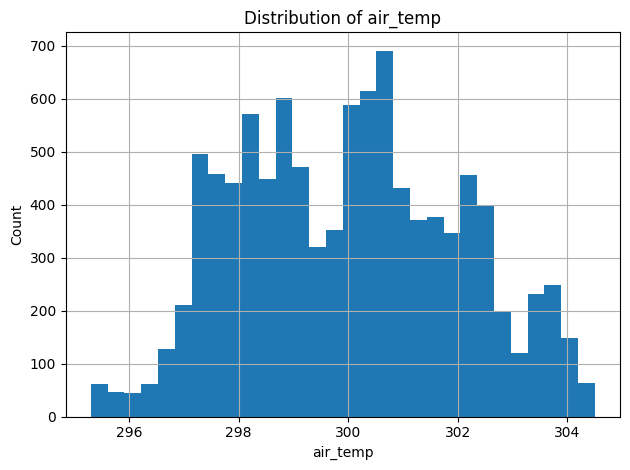

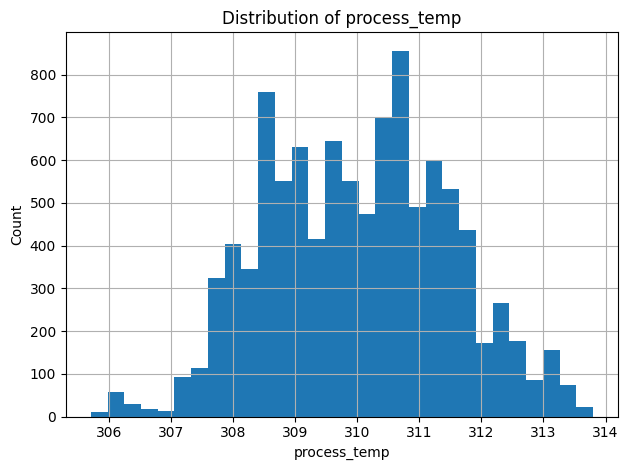

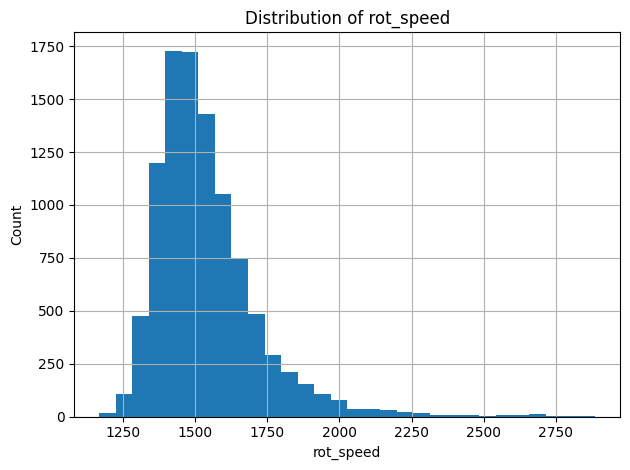

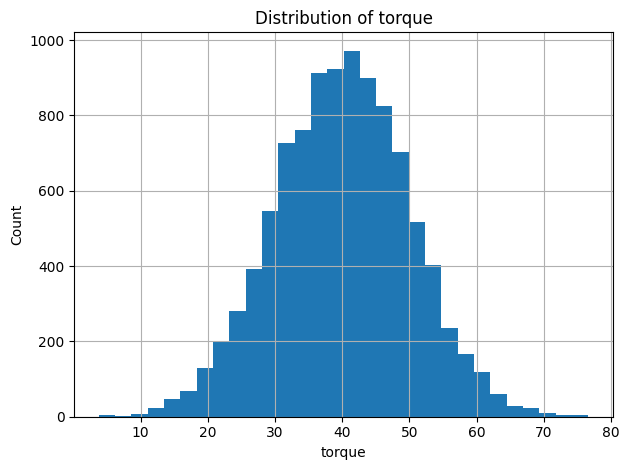

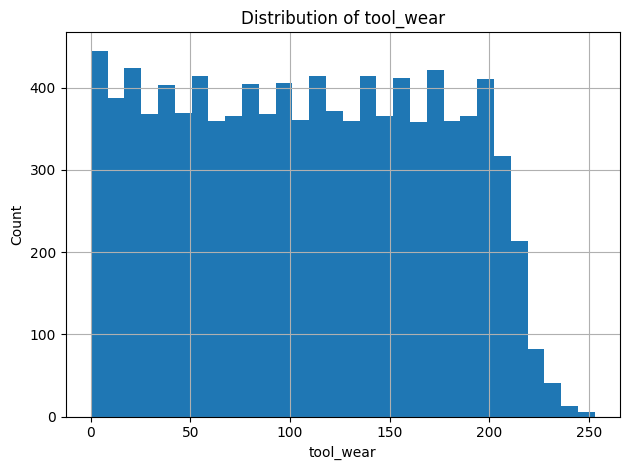

In [31]:
for col in sensor_cols:
    plt.figure()
    df[col].hist(bins=30)
    
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.tight_layout()
    
    plt.savefig(FIGURE_DIR / f"distribution_{col}.png")
    plt.show()

## 히스토그램을 통한 주요 센서 변수의 분포를 확인 결과

온도 변수인 `air_temp`, `process_temp`는 평균 주변에 비교적 집중된 분포를 보였다.

`rot_speed`와 `torque`는 일부 구간에서 값이 넓게 퍼져 있으며, 이후 이상치 분석에서 추가 확인이 필요하다.

`tool_wear`는 0분부터 253분까지 분포하며, 공구 사용 시간에 따른 고장 여부와의 관계를 이후 단계에서 분석할 수 있다.

# 8. 이상치 분석

센서 변수에 비정상적으로 크거나 작은 값이 존재하는지 확인한다.

이번 단계에서는 boxplot을 사용하여 이상치를 시각적으로 확인하고, IQR 방식을 사용하여 컬럼별 이상치 개수를 계산한다.

이상치는 제조 데이터에서 실제 장비 이상 신호일 수도 있고, 측정 오류일 수도 있으므로 모델링 전에 반드시 확인해야 한다.

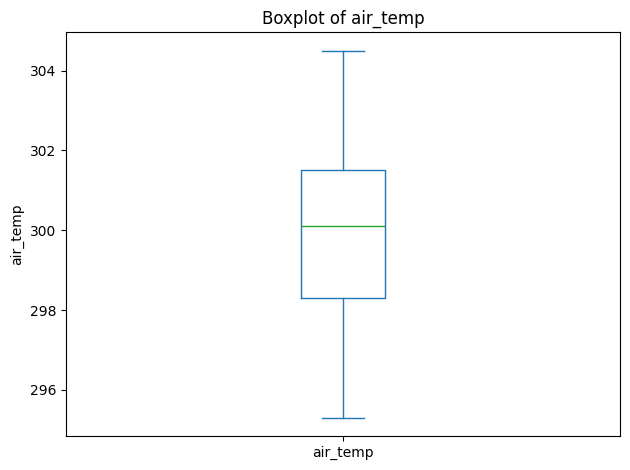

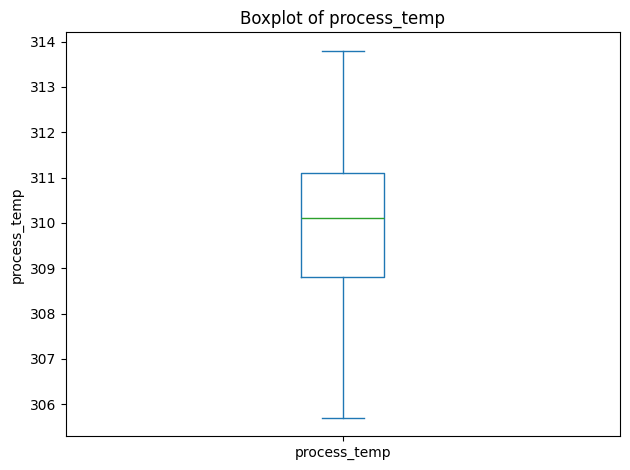

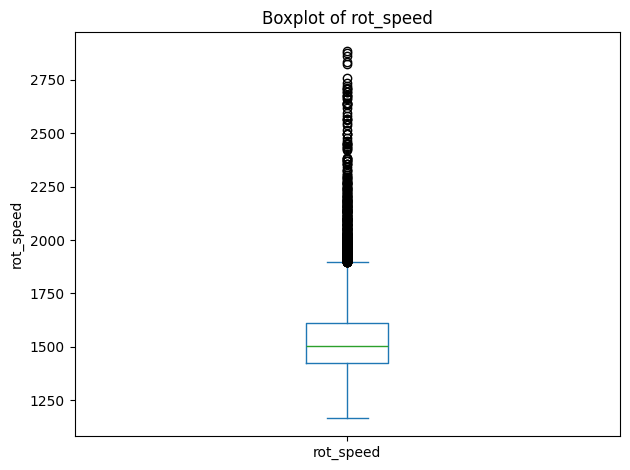

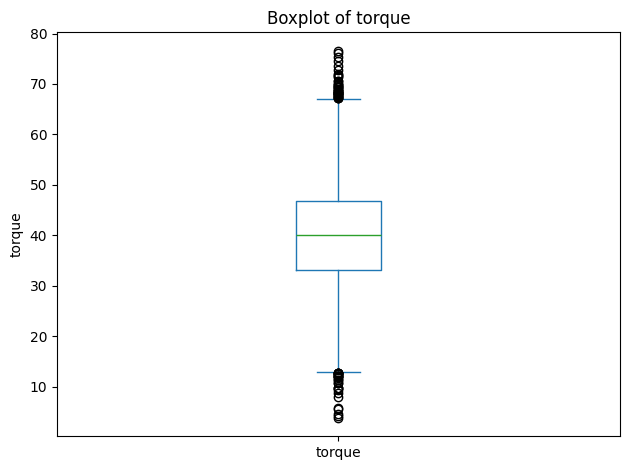

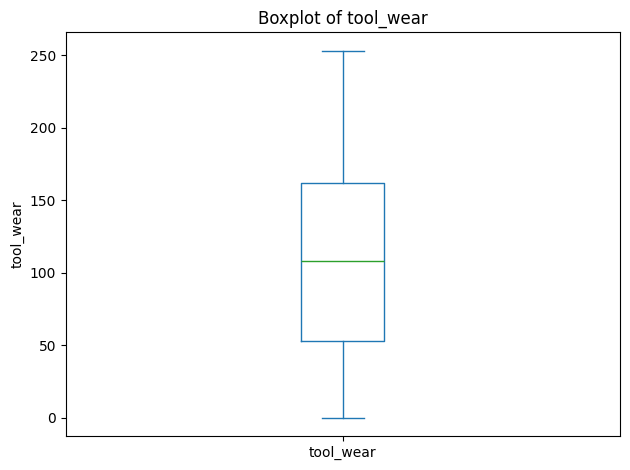

In [32]:
for col in sensor_cols:
    plt.figure()
    df[col].plot(kind="box")
    
    plt.title(f"Boxplot of {col}")
    plt.ylabel(col)
    plt.tight_layout()
    
    plt.savefig(FIGURE_DIR / f"boxplot_{col}.png")
    plt.show()

In [33]:
def count_outliers_iqr(data, col):
    q1 = data[col].quantile(0.25)
    q3 = data[col].quantile(0.75)
    iqr = q3 - q1
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    
    outlier_count = ((data[col] < lower_bound) | (data[col] > upper_bound)).sum()
    
    return outlier_count, lower_bound, upper_bound

In [34]:
outlier_results = []

for col in sensor_cols:
    count, lower, upper = count_outliers_iqr(df, col)
    
    outlier_results.append({
        "column": col,
        "outlier_count": count,
        "lower_bound": lower,
        "upper_bound": upper
    })

outlier_report = pd.DataFrame(outlier_results)
outlier_report

,column,outlier_count,lower_bound,upper_bound
0,air_temp,0,293.50,306.30
1,process_temp,0,305.35,314.55
2,rot_speed,418,1139.50,1895.50
3,torque,69,12.80,67.20
4,tool_wear,0,-110.50,325.50


In [35]:
outlier_report.to_csv(
    REPORT_DIR / "outlier_report.csv",
    index=False,
    encoding="utf-8-sig"
)

## 이상치 분석 결과

센서 변수별 boxplot과 IQR 방식을 사용하여 이상치 후보를 확인하였다.

IQR 기준 이상치 개수를 계산한 결과, `air_temp`, `process_temp`, `tool_wear`에서는 이상치 후보가 확인되지 않았다.

반면 `rot_speed`에서는 418개의 이상치 후보가 확인되었다. IQR 기준 정상 범위는 약 1139.50rpm에서 1895.50rpm이며, 이 범위를 벗어나는 회전 속도 값들이 존재한다. 앞선 기초 통계량에서 `rot_speed`의 최댓값이 2886rpm으로 확인되었기 때문에, 특히 높은 회전 속도 구간의 값들이 이상치 후보에 포함되었을 가능성이 있다.

`torque`에서는 69개의 이상치 후보가 확인되었다. IQR 기준 정상 범위는 약 12.80Nm에서 67.20Nm이며, 이 범위보다 낮거나 높은 토크 값들이 일부 존재한다.

제조 데이터에서 이상치는 단순한 측정 오류일 수도 있지만, 실제 장비 이상 상태나 고장과 관련된 신호일 수도 있다. 따라서 이번 단계에서는 이상치를 제거하지 않고, 이후 고장 여부와의 관계 분석에서 함께 확인한다.

생성한 이상치 분석 리포트는 `reports/outlier_report.csv` 파일로 저장하였다.

이번 이상치 분석에서는 IQR 방식을 사용하였다.

IQR 방식은 Q1과 Q3를 기준으로 데이터의 가운데 50% 범위를 계산하고, 이 범위에서 크게 벗어나는 값을 이상치 후보로 판단한다.

제조 센서 데이터는 정규분포를 따른다고 가정하기 어렵고, 평균과 표준편차가 극단값의 영향을 받을 수 있으므로 Z-score보다 IQR 방식이 EDA 단계에서 더 안정적으로 사용할 수 있다.

또한 IQR 방식은 boxplot과 연결되어 시각적 해석이 쉽기 때문에, 본 프로젝트의 이상치 탐색 방법으로 적합하다.

다만 IQR 기준으로 탐지된 값은 이상치 후보일 뿐이며, 실제 오류값인지 고장 전조 신호인지는 이후 고장 여부와의 관계 분석을 통해 추가로 확인해야 한다.

이상치 탐지 방식 후보
 - IQR : Q1, Q3, 사분위 범위
 - Z-score : 평균, 표준편차
 - Percentile : 상위/하위 n%
 - Isolation Forest : 머신러닝 기반
 - LOF : 주변 밀도 기반
 - 도메인 기준 : 장비 스펙, 공정 기준

# 9. 고장 여부별 센서값 비교

이번 단계에서는 `failure` 값을 기준으로 정상 데이터와 고장 데이터를 나누어 주요 센서 변수의 평균값을 비교한다.

`failure = 0`은 정상 상태, `failure = 1`은 기계 고장 상태를 의미한다.

고장 여부에 따라 센서값의 평균이나 분포가 다르게 나타난다면, 해당 센서 변수가 고장 발생과 관련된 feature일 가능성이 있다.

In [36]:
failure_sensor_mean = df.groupby("failure")[sensor_cols].mean()

failure_sensor_mean

,air_temp,process_temp,rot_speed,torque,tool_wear
failure,,,,,
0,299.973999,309.995570,1540.260014,39.629655,106.693717
1,300.886431,310.290265,1496.486726,50.168142,143.781711


In [37]:
sensor_mean_diff = failure_sensor_mean.loc[1] - failure_sensor_mean.loc[0]

sensor_mean_diff

air_temp         0.912432
process_temp     0.294696
rot_speed      -43.773289
torque          10.538486
tool_wear       37.087994
dtype: float64

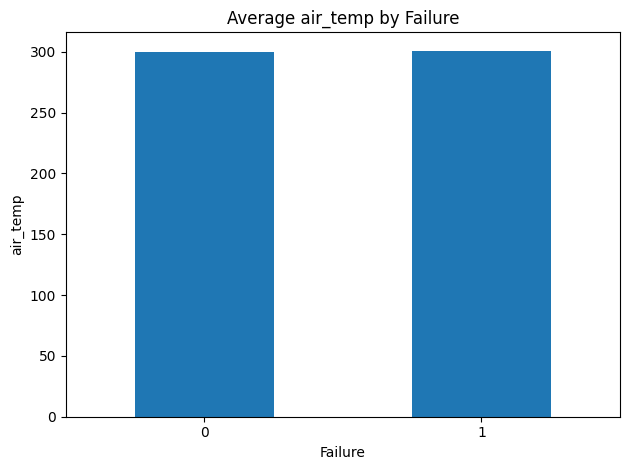

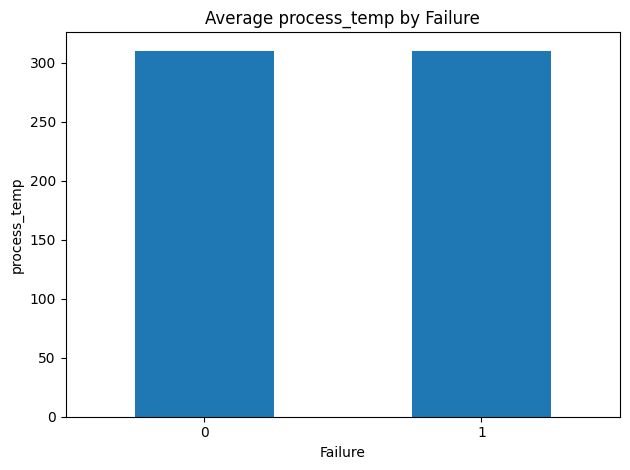

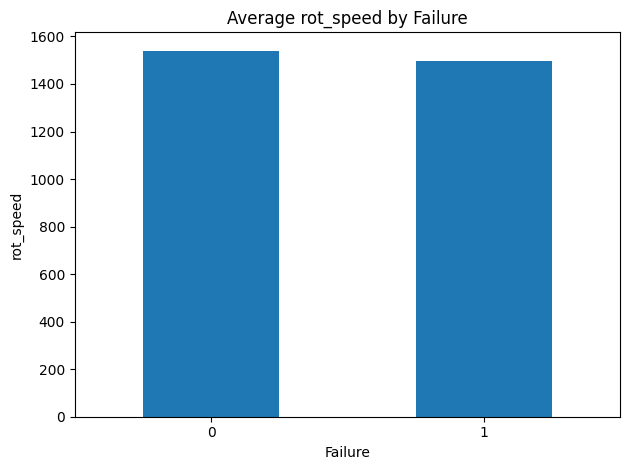

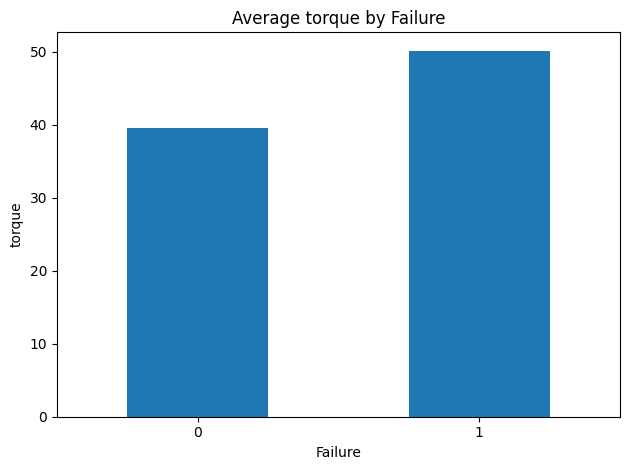

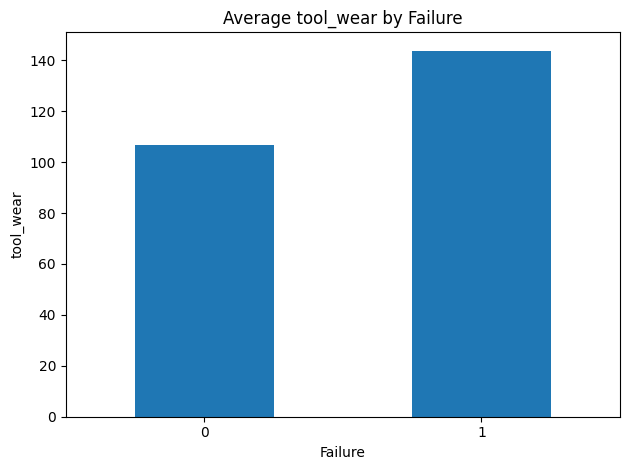

In [38]:
for col in sensor_cols:
    df.groupby("failure")[col].mean().plot(kind="bar")
    
    plt.title(f"Average {col} by Failure")
    plt.xlabel("Failure")
    plt.ylabel(col)
    plt.xticks(rotation=0)
    plt.tight_layout()
    
    plt.savefig(FIGURE_DIR / f"avg_{col}_by_failure.png")
    plt.show()

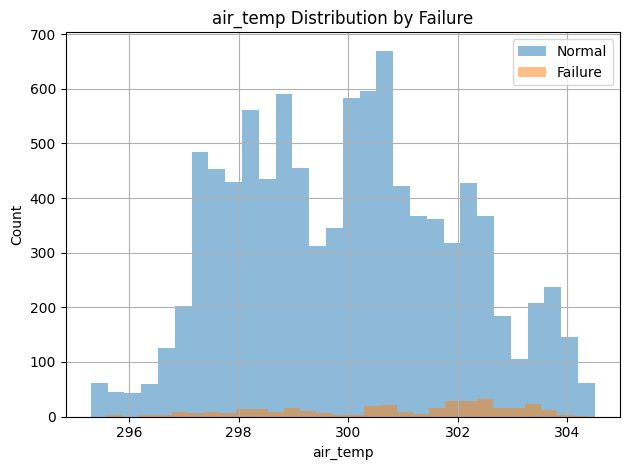

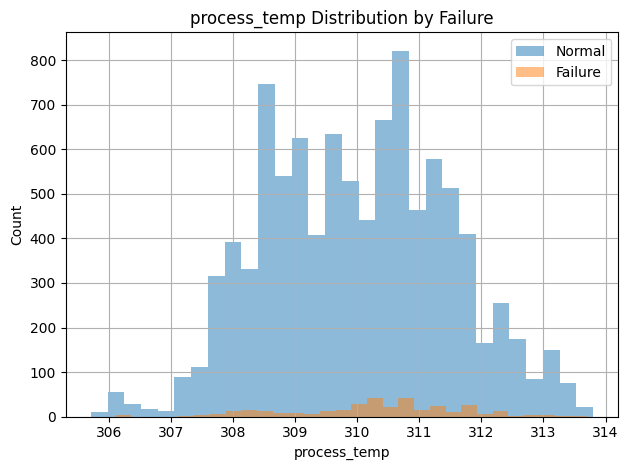

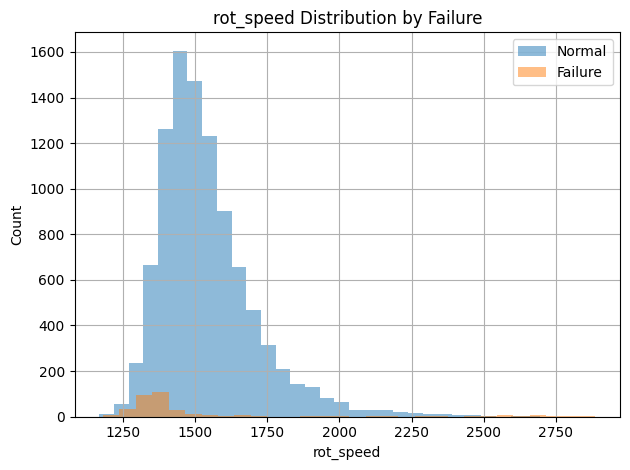

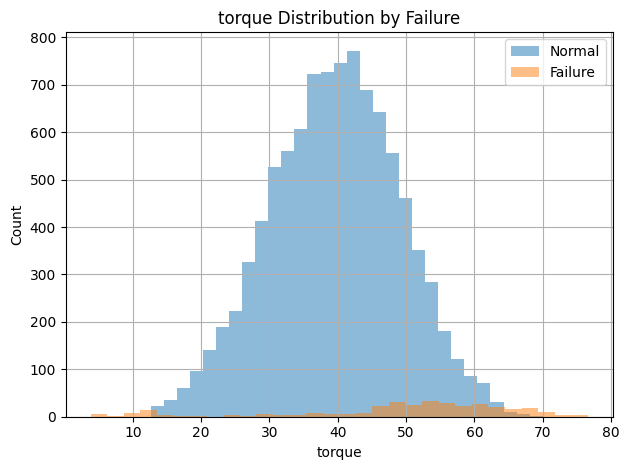

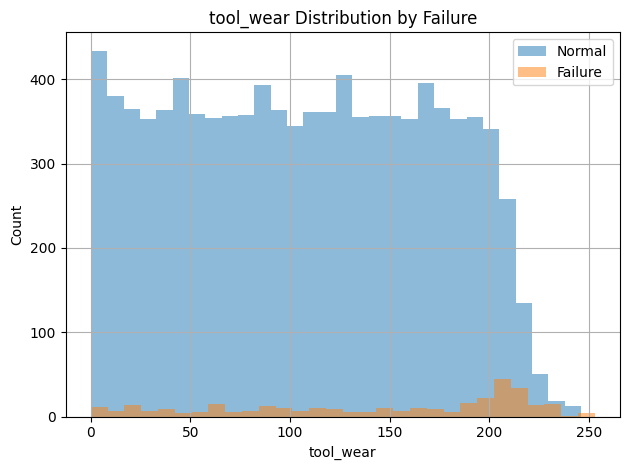

In [39]:
for col in sensor_cols:
    plt.figure()
    
    df[df["failure"] == 0][col].hist(
        bins=30,
        alpha=0.5,
        label="Normal"
    )
    
    df[df["failure"] == 1][col].hist(
        bins=30,
        alpha=0.5,
        label="Failure"
    )
    
    plt.title(f"{col} Distribution by Failure")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    
    plt.savefig(FIGURE_DIR / f"{col}_distribution_by_failure.png")
    plt.show()

## 고장 여부별 센서값 비교 결과

`failure` 값을 기준으로 정상 데이터와 고장 데이터를 나누어 주요 센서 변수의 평균값을 비교하였다.

분석 결과, 고장 데이터는 정상 데이터에 비해 `air_temp`와 `process_temp`가 약간 높게 나타났다. 다만 두 온도 변수의 평균 차이는 각각 약 0.91K, 0.29K로 크지 않았다.

반면 장비 작동 상태와 관련된 변수에서는 더 뚜렷한 차이가 확인되었다. 고장 데이터의 `rot_speed` 평균은 정상 데이터보다 약 43.77rpm 낮았고, `torque` 평균은 약 10.54Nm 높았다. 또한 `tool_wear` 평균은 정상 데이터보다 약 37.09분 높게 나타났다.

즉, 이 데이터에서는 고장 상태가 정상 상태에 비해 낮은 회전 속도, 높은 토크, 높은 공구 마모 시간과 관련되어 있을 가능성이 있다.

다만 평균 차이가 존재한다고 해서 해당 센서 변수가 고장의 직접적인 원인이라고 단정할 수는 없다. 이후 상관관계 분석과 분포 비교를 통해 센서 변수와 고장 여부 간의 관계를 추가로 확인할 필요가 있다.

# 10. 상관관계 분석

이번 단계에서는 주요 센서 변수와 고장 여부 라벨 간의 상관관계를 분석한다.

상관관계는 두 변수가 함께 증가하거나 감소하는 경향을 수치로 나타낸 값이다.

상관계수는 -1에서 1 사이의 값을 가지며, 일반적으로 다음과 같이 해석할 수 있다.

- 1에 가까울수록 양의 상관관계
- -1에 가까울수록 음의 상관관계
- 0에 가까울수록 선형 관계가 약함

다만 상관관계가 높다고 해서 반드시 원인 관계를 의미하는 것은 아니다.

In [40]:
corr = df[sensor_cols + ["failure"]].corr()

corr

,air_temp,process_temp,rot_speed,torque,tool_wear,failure
air_temp,1.000000,0.876107,0.022670,-0.013778,0.013853,0.082556
process_temp,0.876107,1.000000,0.019277,-0.014061,0.013488,0.035946
rot_speed,0.022670,0.019277,1.000000,-0.875027,0.000223,-0.044188
torque,-0.013778,-0.014061,-0.875027,1.000000,-0.003093,0.191321
tool_wear,0.013853,0.013488,0.000223,-0.003093,1.000000,0.105448
failure,0.082556,0.035946,-0.044188,0.191321,0.105448,1.000000


In [41]:
failure_corr = corr["failure"].sort_values(ascending=False)

failure_corr

failure         1.000000
torque          0.191321
tool_wear       0.105448
air_temp        0.082556
process_temp    0.035946
rot_speed      -0.044188
Name: failure, dtype: float64

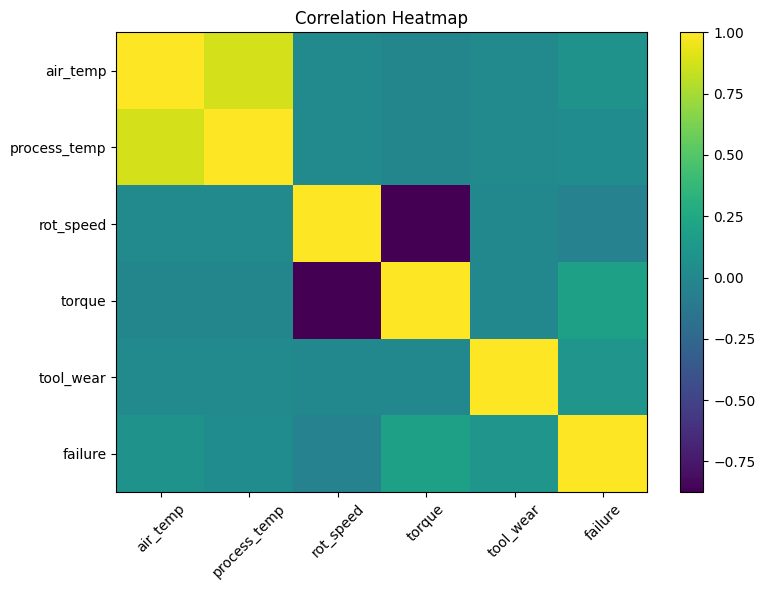

In [42]:
plt.figure(figsize=(8, 6))

plt.imshow(corr, aspect="auto")
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.index)), corr.index)

plt.title("Correlation Heatmap")
plt.tight_layout()

plt.savefig(FIGURE_DIR / "correlation_heatmap.png")
plt.show()

## 상관관계 분석 결과

주요 센서 변수와 `failure` 컬럼 간의 상관관계를 계산하였다.

분석 결과, `failure`와 가장 큰 양의 상관관계를 보인 변수는 `torque`로, 상관계수는 약 0.191로 나타났다. 이는 토크가 높을수록 고장 데이터와 함께 나타나는 경향이 상대적으로 크다는 것을 의미한다.

`tool_wear`는 `failure`와 약 0.105의 양의 상관관계를 보였다. 앞선 고장 여부별 평균 비교에서도 고장 데이터의 공구 마모 시간이 정상 데이터보다 높게 나타났으므로, 공구 마모 시간은 고장 여부와 관련된 feature 후보로 볼 수 있다.

`rot_speed`는 `failure`와 약 -0.044의 음의 상관관계를 보였다. 이는 회전 속도가 낮을수록 고장 데이터와 관련될 가능성이 약하게 나타났다는 의미이다. 앞선 평균 비교에서도 고장 데이터의 회전 속도가 정상 데이터보다 낮게 나타났다.

센서 변수 간 상관관계에서는 `air_temp`와 `process_temp`가 약 0.876의 강한 양의 상관관계를 보였고, `rot_speed`와 `torque`는 약 -0.875의 강한 음의 상관관계를 보였다. 이는 회전 속도와 토크가 서로 반대 방향으로 움직이는 경향이 강하다는 것을 의미한다.

다만 `failure`와 각 센서 변수의 상관계수는 전반적으로 크지 않으므로, 단일 센서 변수만으로 고장 여부를 설명하기는 어렵다. 이후 모델링 단계에서는 여러 센서 변수를 함께 사용하여 고장 예측 모델을 구성할 필요가 있다.

상관관계는 변수 간의 선형적인 관계를 나타낼 뿐이며, 고장의 직접적인 원인을 의미하지는 않는다.

# 11. Train/Test Split

머신러닝 모델을 학습하기 전에 데이터를 입력 feature와 정답 label로 분리한다.

이번 프로젝트에서는 주요 센서 변수인 `air_temp`, `process_temp`, `rot_speed`, `torque`, `tool_wear`를 입력 feature로 사용하고, 기계 고장 여부를 나타내는 `failure` 컬럼을 정답 label로 사용한다.

이후 `train_test_split`을 사용하여 데이터를 학습용 데이터와 테스트용 데이터로 나눈다.

제조 데이터에서는 정상 데이터와 고장 데이터의 비율이 불균형할 수 있으므로, `stratify=y` 옵션을 사용하여 train/test 데이터에서도 라벨 비율이 유지되도록 한다.

In [43]:
X = df[sensor_cols]
y = df["failure"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (10000, 5)
y shape: (10000,)


In [44]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [45]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (8000, 5)
X_test: (2000, 5)
y_train: (8000,)
y_test: (2000,)


In [46]:
print("Original failure ratio:")
display(y.value_counts(normalize=True) * 100)

print("Train failure ratio:")
display(y_train.value_counts(normalize=True) * 100)

print("Test failure ratio:")
display(y_test.value_counts(normalize=True) * 100)

Original failure ratio:


failure
0    96.61
1     3.39
Name: proportion, dtype: float64

Train failure ratio:


failure
0    96.6125
1     3.3875
Name: proportion, dtype: float64

Test failure ratio:


failure
0    96.6
1     3.4
Name: proportion, dtype: float64

## Train/Test Split 결과

주요 센서 변수 5개를 입력 feature `X`로 설정하고, 기계 고장 여부를 나타내는 `failure` 컬럼을 정답 label `y`로 설정하였다.

전체 데이터 10,000개 중 80%인 8,000개는 학습용 데이터로, 20%인 2,000개는 테스트용 데이터로 분리하였다.

제조 데이터는 고장 데이터의 비율이 정상 데이터보다 낮은 클래스 불균형 데이터이므로, `stratify=y` 옵션을 사용하여 train/test 데이터에서도 정상과 고장의 비율이 원본 데이터와 유사하게 유지되도록 하였다.

분리 결과, 원본 데이터와 train/test 데이터의 라벨 비율이 거의 동일하게 유지되었음을 확인하였다.

# 12. 10만 행 이상 데이터 처리 연습

AI4I 데이터셋은 원본 기준 10,000행으로 구성되어 있다.

이번 단계에서는 Pandas로 10만 행 이상 데이터를 처리하는 연습을 위해 원본 데이터를 10번 복제하여 100,000행 규모의 DataFrame을 생성한다.

생성한 대용량 DataFrame에 대해 기본 정보 확인, 기초 통계량 계산, groupby 집계, 메모리 사용량 확인을 수행한다.

이 과정은 실제 대용량 제조 데이터를 다루기 전 Pandas 처리 흐름을 연습하기 위한 목적이다.

In [47]:
df_big = pd.concat([df] * 10, ignore_index=True)

print(df_big.shape)
df_big.head()

(100000, 14)


,UDI,Product ID,Type,air_temp,process_temp,rot_speed,torque,tool_wear,failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [48]:
df_big.info(memory_usage="deep")

<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   UDI           100000 non-null  int64  
 1   Product ID    100000 non-null  str    
 2   Type          100000 non-null  str    
 3   air_temp      100000 non-null  float64
 4   process_temp  100000 non-null  float64
 5   rot_speed     100000 non-null  int64  
 6   torque        100000 non-null  float64
 7   tool_wear     100000 non-null  int64  
 8   failure       100000 non-null  int64  
 9   TWF           100000 non-null  int64  
 10  HDF           100000 non-null  int64  
 11  PWF           100000 non-null  int64  
 12  OSF           100000 non-null  int64  
 13  RNF           100000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
memory usage: 19.2 MB


In [49]:
df_big[sensor_cols].describe()

,air_temp,process_temp,rot_speed,torque,tool_wear
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,300.004930,310.005560,1538.776100,39.986910,107.951000
std,2.000169,1.483667,179.276028,9.968485,63.651282
min,295.300000,305.700000,1168.000000,3.800000,0.000000
25%,298.300000,308.800000,1423.000000,33.200000,53.000000
50%,300.100000,310.100000,1503.000000,40.100000,108.000000
75%,301.500000,311.100000,1612.000000,46.800000,162.000000
max,304.500000,313.800000,2886.000000,76.600000,253.000000


In [50]:
df_big.groupby("Type")["failure"].mean() * 100

Type
H    2.093719
L    3.916667
M    2.769436
Name: failure, dtype: float64

In [51]:
before_memory = df_big.memory_usage(deep=True).sum() / 1024**2
print(f"최적화 전 메모리 사용량: {before_memory:.2f} MB")


df_big_optimized = df_big.copy()

df_big_optimized["Type"] = df_big_optimized["Type"].astype("category")
df_big_optimized["failure"] = df_big_optimized["failure"].astype("int8")
df_big_optimized["TWF"] = df_big_optimized["TWF"].astype("int8")
df_big_optimized["HDF"] = df_big_optimized["HDF"].astype("int8")
df_big_optimized["PWF"] = df_big_optimized["PWF"].astype("int8")
df_big_optimized["OSF"] = df_big_optimized["OSF"].astype("int8")
df_big_optimized["RNF"] = df_big_optimized["RNF"].astype("int8")


after_memory = df_big_optimized.memory_usage(deep=True).sum() / 1024**2
print(f"최적화 후 메모리 사용량: {after_memory:.2f} MB")
print(f"감소량: {before_memory - after_memory:.2f} MB")

최적화 전 메모리 사용량: 19.17 MB
최적화 후 메모리 사용량: 10.49 MB
감소량: 8.68 MB


## 10만 행 이상 데이터 처리 결과

원본 AI4I 데이터셋은 10,000행으로 구성되어 있으므로, Pandas의 `concat`을 사용하여 데이터를 10번 복제하고 100,000행 규모의 DataFrame을 생성하였다.

생성한 `df_big` DataFrame에 대해 `info()`, `describe()`, `groupby()` 연산을 수행하여 10만 행 이상의 데이터도 Pandas로 처리할 수 있음을 확인하였다.

또한 데이터 타입 최적화를 통해 메모리 사용량을 감소시켰다. 특히 `Type`과 같은 범주형 변수는 `category` 타입으로 변환하고, 0/1 값만 가지는 이진 변수는 `int8` 타입으로 변환하여 메모리 사용량을 절감할 수 있었다.
